# Why adaptive sampling matters

KiwiCalc uses uniformly spaced x coordinates by default and joins adjacent finite results with straight line segments. That is fast, deterministic, and often exactly what users expect—but it can produce a convincing picture of the wrong function.

This notebook demonstrates three failures of fixed sampling, explains the performance tradeoff with a small teaching prototype, and then exercises KiwiCalc's production adaptive sampler.

In [1]:
from time import perf_counter
import inspect
import math
import matplotlib.pyplot as plt
import numpy as np
import kiwicalc as kw

print('KiwiCalc loaded from:', inspect.getfile(kw.plot_function))

KiwiCalc loaded from: C:\Users\lenovo-pc\Desktop\data projects\kiwicalc\kiwicalc\plotting\plots.py


## A minimal instrumented prototype

The prototype evaluates the midpoint of each fixed interval. It subdivides only when that midpoint differs materially from the straight line joining the endpoints. Results are cached, and `max_depth` and `max_points` impose hard work limits.

In [2]:
def demo_adaptive_sample(function, start, stop, *, initial_step, tolerance=1e-3, max_depth=12, max_points=5000):
    cache = {}

    def evaluate(x):
        x = float(x)
        if x not in cache:
            try:
                value = float(function(x))
                cache[x] = value if math.isfinite(value) else np.nan
            except (ArithmeticError, TypeError, ValueError, OverflowError):
                cache[x] = np.nan
        return cache[x]

    initial = list(np.arange(start, stop, initial_step, dtype=float)) + [float(stop)]
    for x in initial:
        evaluate(x)

    def refine(left, right, depth):
        if depth >= max_depth or len(cache) >= max_points:
            return
        middle = (left + right) / 2
        left_y, middle_y, right_y = evaluate(left), evaluate(middle), evaluate(right)
        if not np.isfinite([left_y, middle_y, right_y]).all():
            return  # the NaN at middle breaks the rendered line
        linear_middle = (left_y + right_y) / 2
        scale = 1 + max(abs(left_y), abs(middle_y), abs(right_y))
        if abs(middle_y - linear_middle) > tolerance * scale:
            refine(left, middle, depth + 1)
            refine(middle, right, depth + 1)

    for left, right in zip(initial[:-1], initial[1:]):
        refine(left, right, 0)

    x = np.array(sorted(cache))
    y = np.array([cache[value] for value in x])
    return x, y, len(cache)

## Failure 1: aliasing makes an oscillating function look flat

At `step=0.01`, every fixed sample lands almost exactly on a zero of this sine wave. The current plot therefore looks like `y=0`, even though the function repeatedly reaches −1 and +1.

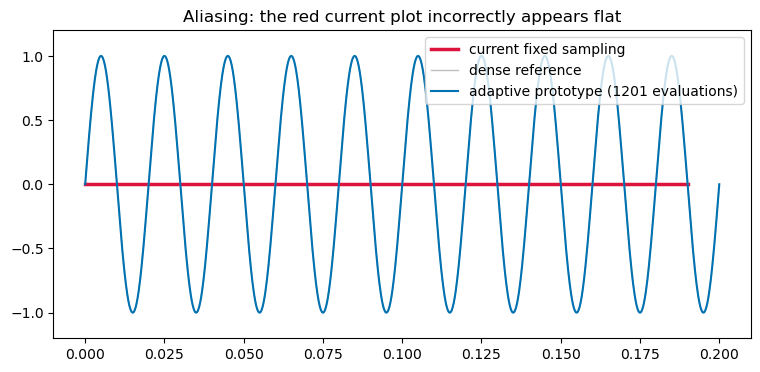

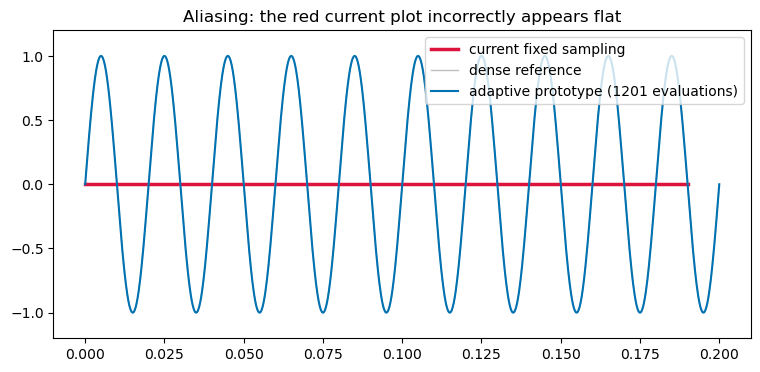

In [3]:
oscillation = lambda x: np.sin(100 * np.pi * x)
fig, ax = plt.subplots(figsize=(9, 4))
current = kw.plot_function(oscillation, start=0, stop=0.2, step=0.01, ymin=-1.2, ymax=1.2, show_axis=False, show=False, fig=fig, ax=ax, color='crimson', linewidth=2.5, label='current fixed sampling')
dense_x = np.linspace(0, 0.2, 4001)
ax.plot(dense_x, oscillation(dense_x), color='0.75', linewidth=1, label='dense reference')
adaptive_x, adaptive_y, oscillation_evaluations = demo_adaptive_sample(oscillation, 0, 0.2, initial_step=0.01)
ax.plot(adaptive_x, adaptive_y, color='#0072B2', linewidth=1.5, label=f'adaptive prototype ({oscillation_evaluations} evaluations)')
ax.set_title('Aliasing: the red current plot incorrectly appears flat')
ax.legend(loc='upper right')
assert np.max(np.abs(np.asarray(current.get_ydata(), dtype=float))) < 1e-10
assert np.max(np.abs(oscillation(dense_x))) > 0.99
fig

## Failure 2: a narrow peak falls entirely between samples

The fixed samples see values indistinguishable from zero. The actual function reaches one halfway between two samples. This matters for resonance curves, probability densities, optimization plots, and localized numerical solutions.

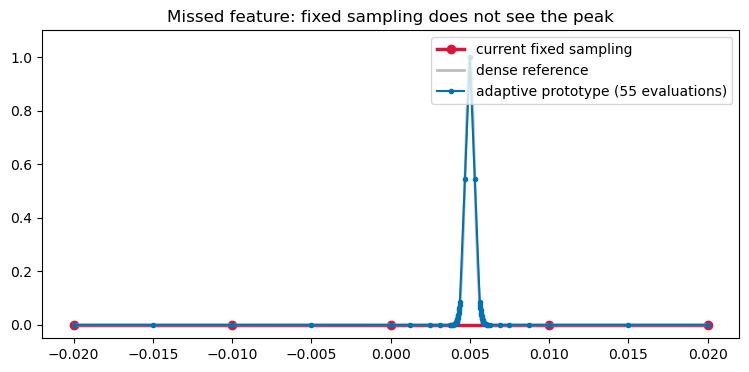

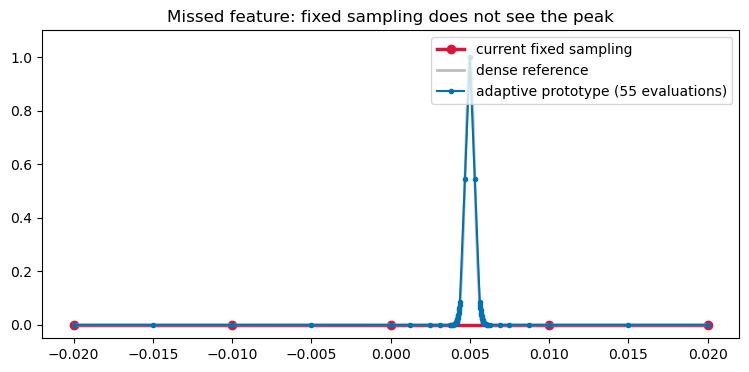

In [4]:
spike = lambda x: np.exp(-((x - 0.005) / 0.0004) ** 2)
fig, ax = plt.subplots(figsize=(9, 4))
current = kw.plot_function(spike, start=-0.02, stop=0.02, step=0.01, ymin=-0.05, ymax=1.1, show_axis=False, show=False, fig=fig, ax=ax, color='crimson', marker='o', linewidth=2.5, label='current fixed sampling')
dense_x = np.linspace(-0.02, 0.02, 4001)
ax.plot(dense_x, spike(dense_x), color='0.75', linewidth=2, label='dense reference')
adaptive_x, adaptive_y, spike_evaluations = demo_adaptive_sample(spike, -0.02, 0.02, initial_step=0.01)
ax.plot(adaptive_x, adaptive_y, color='#0072B2', marker='.', linewidth=1.5, label=f'adaptive prototype ({spike_evaluations} evaluations)')
ax.set_title('Missed feature: fixed sampling does not see the peak')
ax.legend(loc='upper right')
assert np.max(np.asarray(current.get_ydata(), dtype=float)) < 1e-20
assert np.max(spike(dense_x)) > 0.99
fig

## Failure 3: a pole becomes a false connecting line

Because the undefined x coordinate lies between fixed samples, both neighboring values are finite and Matplotlib connects them. The resulting near-vertical segment falsely implies that the function crosses every intermediate y value. An adaptive midpoint check encounters the undefined point and inserts a line break.

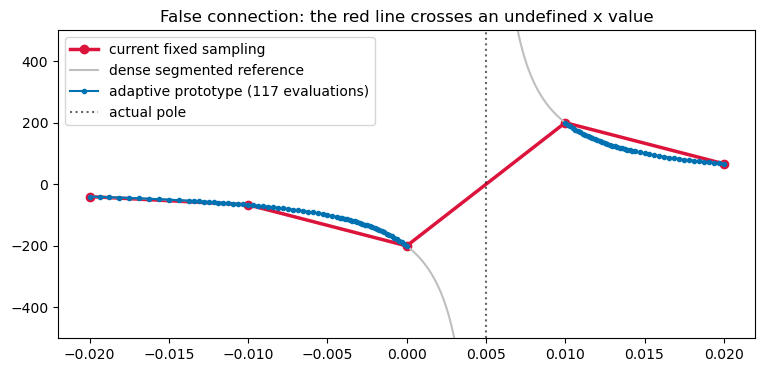

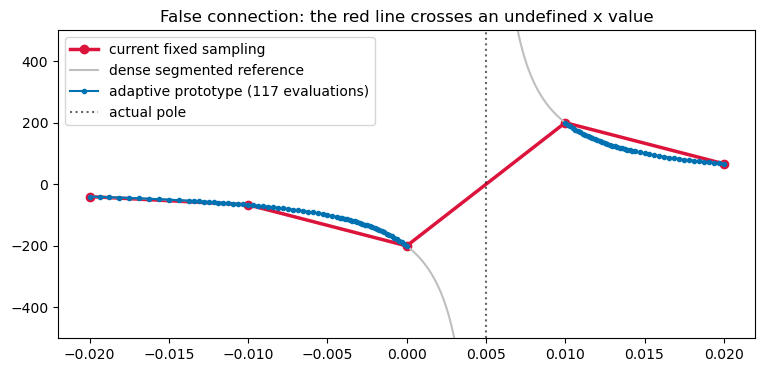

In [5]:
def pole(x):
    if abs(x - 0.005) < 1e-14:
        raise ZeroDivisionError('undefined at the pole')
    return 1 / (x - 0.005)
fig, ax = plt.subplots(figsize=(9, 4))
current = kw.plot_function(pole, start=-0.02, stop=0.02, step=0.01, ymin=-500, ymax=500, show_axis=False, show=False, fig=fig, ax=ax, color='crimson', marker='o', linewidth=2.5, label='current fixed sampling')
dense_x = np.linspace(-0.02, 0.02, 4001)
dense_y = np.divide(1, dense_x - 0.005, out=np.full_like(dense_x, np.nan), where=np.abs(dense_x - 0.005) > 1e-12)
dense_y[np.abs(dense_x - 0.005) < 0.00008] = np.nan
ax.plot(dense_x, dense_y, color='0.75', linewidth=1.5, label='dense segmented reference')
adaptive_x, adaptive_y, pole_evaluations = demo_adaptive_sample(pole, -0.02, 0.02, initial_step=0.01)
ax.plot(adaptive_x, adaptive_y, color='#0072B2', marker='.', linewidth=1.5, label=f'adaptive prototype ({pole_evaluations} evaluations)')
ax.axvline(0.005, color='black', linestyle=':', alpha=0.6, label='actual pole')
ax.set_title('False connection: the red line crosses an undefined x value')
ax.legend(loc='upper left')
assert np.isfinite(np.asarray(current.get_ydata(), dtype=float)).all()
assert np.isnan(adaptive_y).any()
fig

## Performance consequences

Fixed sampling has predictable **O(N)** evaluation cost and works especially well with vectorized NumPy functions. Midpoint-based adaptation performs roughly one extra probe per initial interval even when no refinement is needed. Curved or difficult regions add more points, up to the configured hard limits.

The important comparison is not adaptive versus today's coarse plot; it is adaptive versus the globally dense fixed grid needed to achieve similar reliability. For mostly smooth functions with a small difficult region, adaptation can use far fewer evaluations than a sufficiently dense global grid. For cheap vectorized functions, Python-side adaptive bookkeeping can still make it slower.

In [6]:
def fixed_scalar_sample(function, start, stop, step):
    x = np.arange(start, stop + step / 2, step)
    return x, np.array([function(value) for value in x])

cases = [
    ('smooth line', lambda x: 2*x + 1, -1, 1, 0.01),
    ('aliased wave', oscillation, 0, 0.2, 0.01),
    ('narrow peak', spike, -0.02, 0.02, 0.01),
]
print(f"{'case':<16} {'fixed evals':>12} {'adaptive evals':>15} {'fixed ms':>12} {'adaptive ms':>14}")
for name, function, start, stop, step in cases:
    begin = perf_counter()
    fixed_x, fixed_y = fixed_scalar_sample(function, start, stop, step)
    fixed_ms = (perf_counter() - begin) * 1000
    begin = perf_counter()
    adaptive_x, adaptive_y, evaluations = demo_adaptive_sample(function, start, stop, initial_step=step)
    adaptive_ms = (perf_counter() - begin) * 1000
    print(f'{name:<16} {len(fixed_x):>12} {evaluations:>15} {fixed_ms:>12.3f} {adaptive_ms:>14.3f}')

case              fixed evals  adaptive evals     fixed ms    adaptive ms
smooth line               201             401        0.132          1.949
aliased wave               21            1201        0.071         15.167
narrow peak                 5              55        0.053          0.456


## Try the production KiwiCalc sampler

KiwiCalc now exposes the bounded sampler demonstrated above. Fixed sampling remains the default; passing `sampling='adaptive'` opts in. The returned Matplotlib artist retains a `PlotSample` diagnostic object so the extra work and any truncation are visible rather than hidden.

{'points': 1201, 'evaluations': 1201, 'refined_points': 1180, 'truncated': False}


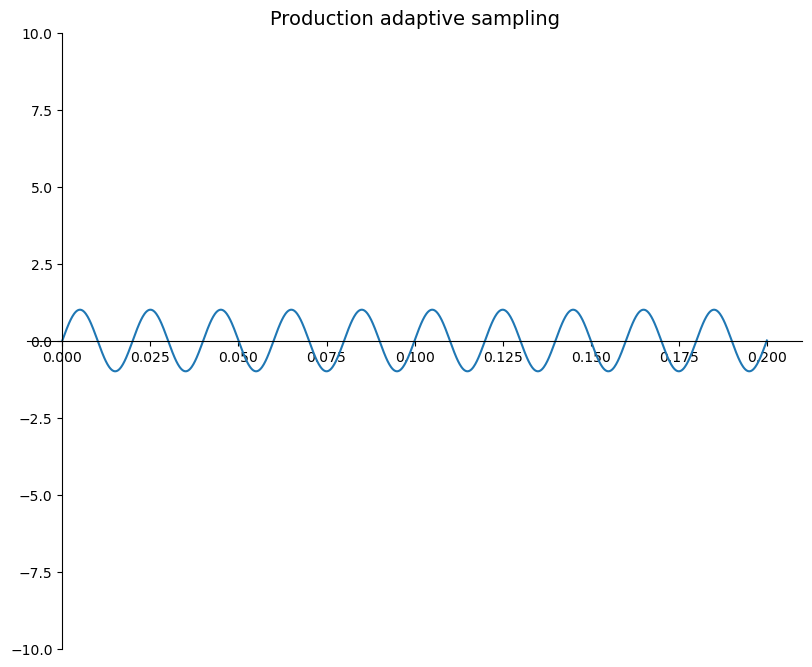

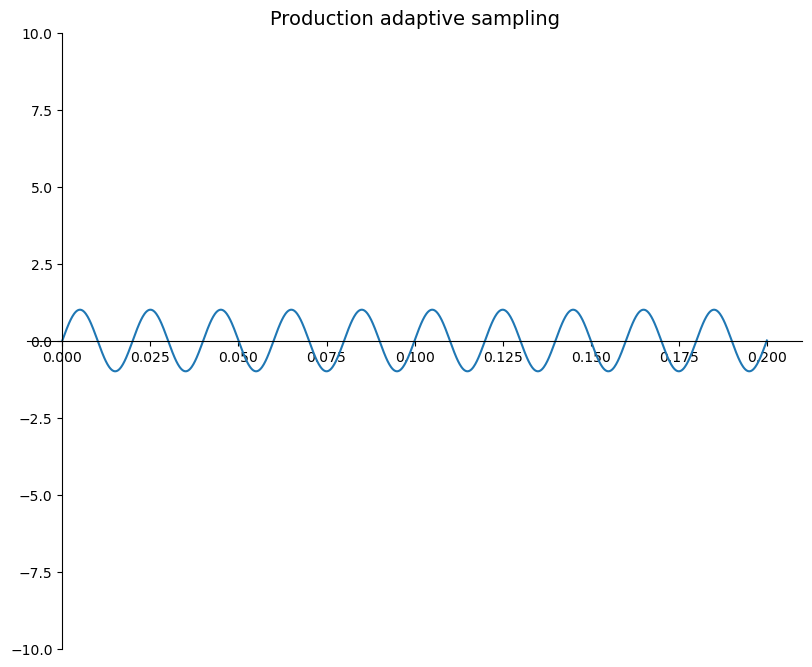

In [7]:
production_line = kw.plot_function(
    oscillation, start=0, stop=0.2, step=0.01,
    sampling='adaptive', tolerance=1e-3,
    max_points=5000, max_depth=12, show=False,
    title='Production adaptive sampling',
)
production_sample = production_line.kiwicalc_sample
print({
    'points': production_sample.point_count,
    'evaluations': production_sample.evaluations,
    'refined_points': production_sample.refined_points,
    'truncated': production_sample.truncated,
})
assert np.max(np.abs(production_line.get_ydata())) > 0.99
assert production_sample.sampling == 'adaptive'
production_line.figure

{'points': 55, 'refined_points': 50, 'truncated': False}


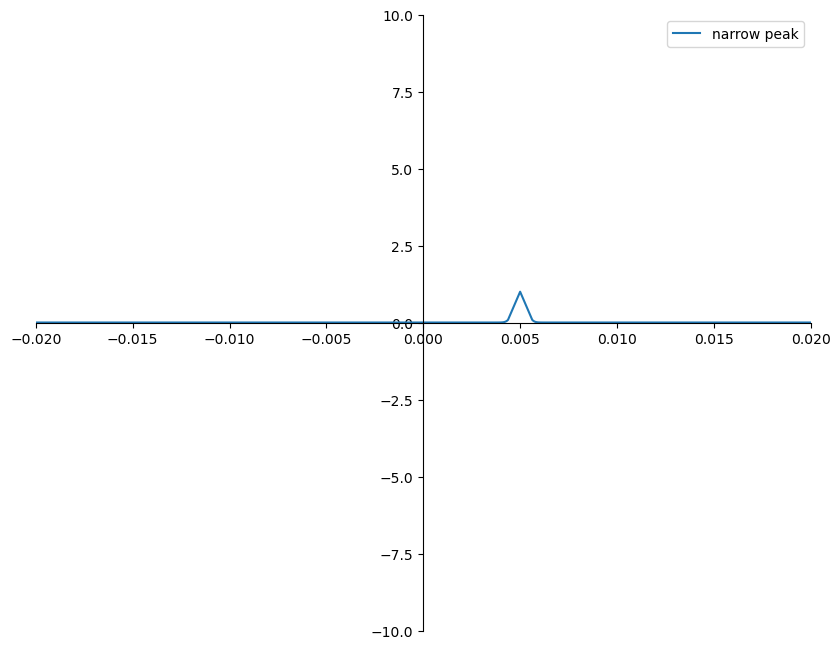

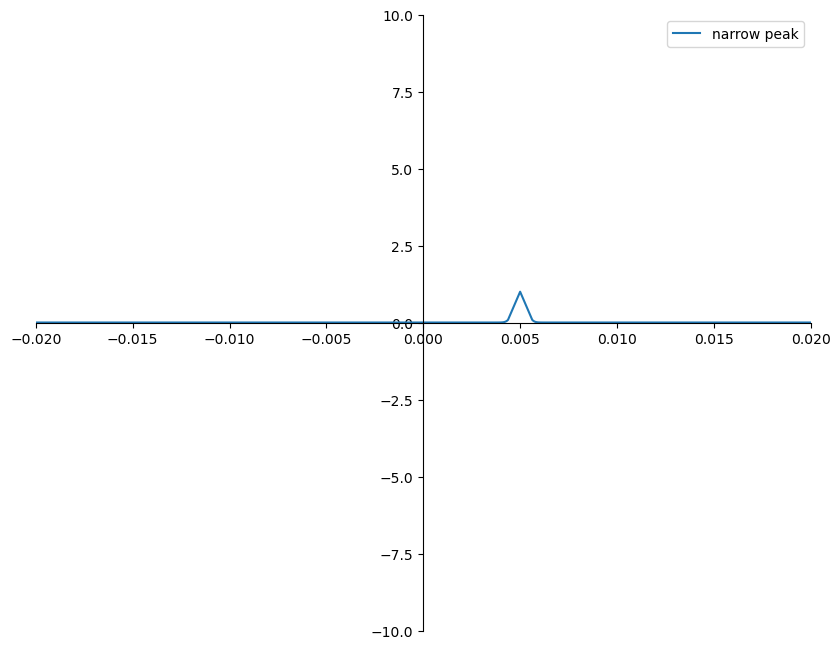

In [8]:
graph = kw.Graph2D().add(spike, label='narrow peak')
graph.plot(
    start=-0.02, stop=0.02, step=0.01,
    sampling='adaptive', show=False, legend=True,
)
print({
    'points': graph.sampling_results[0].point_count,
    'refined_points': graph.sampling_results[0].refined_points,
    'truncated': graph.sampling_results[0].truncated,
})
assert graph.sampling_results[0].refined_points > 0
graph.fig

## Adopted policy: opt in first

KiwiCalc does **not** silently replace fixed sampling. It preserves speed and reproducibility with `sampling='fixed'` as the default and provides this explicit opt-in:

```python
kw.plot_function(
    function,
    sampling='adaptive',
    tolerance=1e-3,
    max_points=5000,
    max_depth=12,
)
```

The production sampler inserts line breaks at detected undefined values, exposes evaluation statistics, uses hard limits, and falls back to scalar evaluation when a function is not vectorized. After real-world benchmarking, KiwiCalc could consider `sampling='auto'`, but fixed sampling should remain available permanently.

No finite sampler can guarantee discovery of an arbitrarily narrow feature it never probes. Adaptive sampling reduces the risk substantially; it does not turn plotting into a proof system.